In [1]:
# ============================================================
# CELL 1 — Environment setup & sys.path
# ============================================================

import sys
import os

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

np_seed = 42 

In [2]:
# ============================================================
# CELL 2 — All imports (consolidated, no duplicates)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression as SklearnLR

from src.linear_regression import LinearRegression as CustomLR
from src.linear_regression_gd import LinearRegressionGD

In [3]:
# ============================================================
# CELL 3 — Load California Housing dataset
# ============================================================

california = fetch_california_housing(as_frame=True)

X = california['data'][['MedInc']]
y = california['target']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature (X) preview:")
print(X.head())
print("\nTarget (y) preview:")
print(y.head())


X shape: (20640, 1)
y shape: (20640,)

Feature (X) preview:
   MedInc
0  8.3252
1  8.3014
2  7.2574
3  5.6431
4  3.8462

Target (y) preview:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [4]:
# ============================================================
# CELL 4 — Train / validation split  (Part 4.1.3)
# ============================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    train_size=100,
    test_size=100,
    random_state=42
)

x_train_arr = X_train["MedInc"].values
x_val_arr   = X_val["MedInc"].values
y_train_arr = y_train.values
y_val_arr   = y_val.values

In [5]:
# ============================================================
# CELL 5 — Part 4.1.1: OLS sanity check
# ============================================================
print("--- Running Sanity Check for OLS ---")

np.random.seed(42)
X_random = np.random.rand(100, 5)
y_random = (3 * X_random[:, 0]
            + 1.5 * X_random[:, 2]
            - 2 * X_random[:, 4]
            + np.random.randn(100) * 0.1)

sk_model = SklearnLR(fit_intercept=True)
sk_model.fit(X_random, y_random)
sk_preds = sk_model.predict(X_random)

my_model = CustomLR()
my_model.fit(X_random, y_random)
my_preds = my_model.predict(X_random)

is_match = np.allclose(sk_preds, my_preds, atol=1e-9)
print(f"Outputs match within 10^-9: {is_match}")
if is_match:
    print("Sanity check passed! Custom OLS is mathematically identical to sklearn.")
else:
    print("Sanity check failed. Check your matrix inversion math in src!")

--- Running Sanity Check for OLS ---
Outputs match within 10^-9: True
Sanity check passed! Custom OLS is mathematically identical to sklearn.


Learning Rate 0.001 converged in 1000 iterations with a final MSE of 391.9509.
Learning Rate 0.01 converged in 823 iterations with a final MSE of 0.2322.
Learning Rate 0.1 converged in 90 iterations with a final MSE of 0.2322.


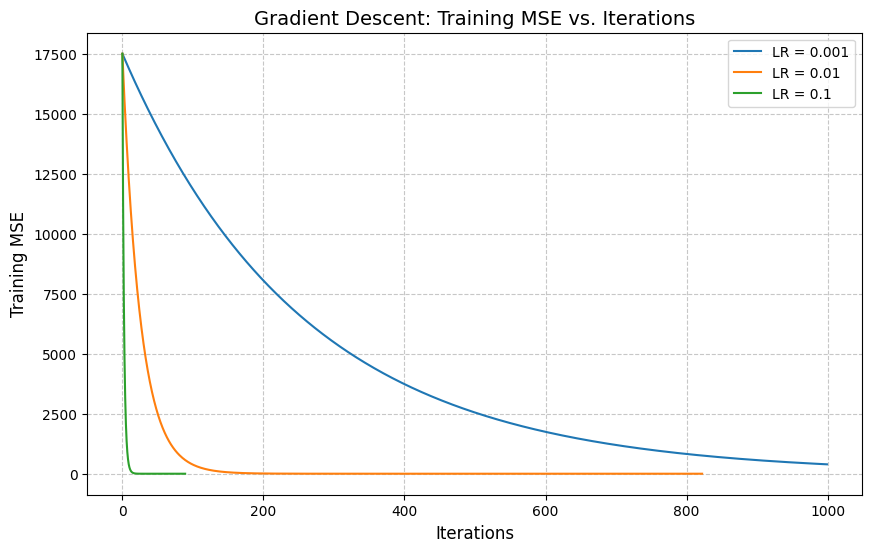

In [6]:
# ============================================================
# CELL 6 — Part 4.1.2: Gradient descent experiments
# ============================================================
X_syn, y_syn = make_regression(n_samples=1000, n_features=10, noise=0.5, random_state=42)

learning_rates = [0.001, 0.01, 0.1]
gd_models = {}

plt.figure(figsize=(10, 6))

for current_lr in learning_rates:
    model_gd = LinearRegressionGD(lr=current_lr)
    model_gd.fit(X_syn, y_syn)
    gd_models[current_lr] = model_gd
    plt.plot(model_gd.loss_history, label=f'LR = {current_lr}')
    
    # Extract the last error from the history
    final_error = model_gd.loss_history[-1]
    
    # Updated print statement formatting the final error to 4 decimal places
    print(f"Learning Rate {current_lr} converged in {len(model_gd.loss_history)} iterations with a final MSE of {final_error:.4f}.")

plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Training MSE', fontsize=12)
plt.title('Gradient Descent: Training MSE vs. Iterations', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('../figures/Gradient_Descent_Training_MSE_Iterations.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# CELL 7 — Part 4.1.2: Compare GD weights with OLS weights
# ============================================================
print("\n--- Weight Comparison (GD vs OLS) ---")

ols_model = CustomLR()
ols_model.fit(X_syn, y_syn)

best_gd_model = gd_models[0.1]
weights_match = np.allclose(best_gd_model.w_weights, ols_model.weights, atol=1e-4)

print(f"Do the GD weights (LR=0.1) match OLS weights within 10^-4? {weights_match}")
if weights_match:
    print("Success! Gradient Descent converged to the exact same global minimum as OLS.")
else:
    print("Failed: Weights did not match perfectly. Double check your gradient math!")


--- Weight Comparison (GD vs OLS) ---
Do the GD weights (LR=0.1) match OLS weights within 10^-4? True
Success! Gradient Descent converged to the exact same global minimum as OLS.


In [8]:
# ============================================================
# CELL 8 — Part 4.1.3: Polynomial fitting & overfitting
# ============================================================
train_mse_list = []
val_mse_list   = []
degrees = range(1, 13)

for d in degrees:
    X_train_poly = np.column_stack([x_train_arr**i for i in range(1, d + 1)])
    X_val_poly   = np.column_stack([x_val_arr**i   for i in range(1, d + 1)])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_val_scaled   = scaler.transform(X_val_poly)

    model = CustomLR()
    model.fit(X_train_scaled, y_train_arr)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred   = model.predict(X_val_scaled)

    train_mse_list.append(mean_squared_error(y_train_arr, y_train_pred))
    val_mse_list.append(mean_squared_error(y_val_arr,   y_val_pred))

print("Experiment loop complete! MSE values successfully stored.")
print(train_mse_list)
print(val_mse_list)

Experiment loop complete! MSE values successfully stored.
[0.6425542440376449, 0.6125081664317754, 0.6121250577105978, 0.5993466756469221, 0.5967329316683178, 0.5863296326782069, 0.5757119029711455, 0.5514246816048096, 0.550803058052713, 0.5508270855498862, 0.5647657208146523, 0.5494528522528216]
[0.76629584692194, 0.7624425654751512, 0.7663375653691108, 0.7572854560146318, 0.7629947414996409, 0.7768353127789591, 0.7543216507684021, 0.745659663509728, 0.7500442782783024, 0.7502926920582169, 0.7511638408416182, 0.7495711396406008]


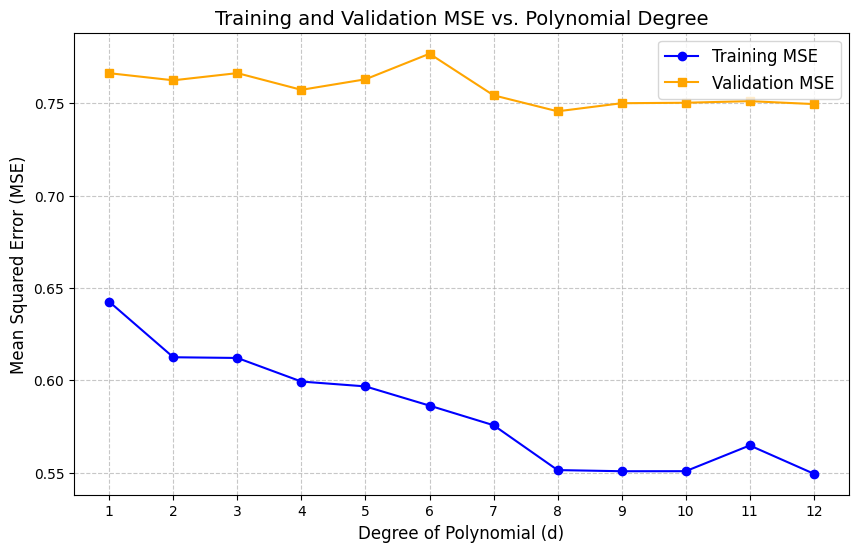

--- Results ---
The degree with the lowest validation MSE is: d = 8
The lowest validation MSE achieved is: 0.7457


In [9]:
# ============================================================
# CELL 9 — Part 4.1.3: Plot Training vs Validation MSE
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mse_list, label='Training MSE',   marker='o', color='blue')
plt.plot(degrees, val_mse_list,   label='Validation MSE', marker='s', color='orange')
plt.xlabel('Degree of Polynomial (d)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Training and Validation MSE vs. Polynomial Degree', fontsize=14)
plt.xticks(degrees)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('../figures/Training and Validation MSE vs. Polynomial Degree.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

best_index    = np.argmin(val_mse_list)
best_d        = list(degrees)[best_index]
lowest_val_mse = val_mse_list[best_index]
print(f"--- Results ---")
print(f"The degree with the lowest validation MSE is: d = {best_d}")
print(f"The lowest validation MSE achieved is: {lowest_val_mse:.4f}")

In [10]:
# ============================================================
# CELL 10 — Part 4.1.5: Prediction intervals (d=5 and d=12)
# ============================================================
import scipy.stats as stats

# ------------------------------------------------------------
# 1. Calculate for d = 5
# ------------------------------------------------------------
d_5 = 5

X_train_poly_5 = np.column_stack([x_train_arr**i for i in range(1, d_5 + 1)])
X_val_poly_5   = np.column_stack([x_val_arr**i   for i in range(1, d_5 + 1)])

scaler_5 = StandardScaler()
X_train_scaled_5 = scaler_5.fit_transform(X_train_poly_5)
X_val_scaled_5   = scaler_5.transform(X_val_poly_5)

model_d5 = CustomLR()
model_d5.fit(X_train_scaled_5, y_train_arr)

X_train_design_5 = np.column_stack([np.ones(len(X_train_scaled_5)), X_train_scaled_5])
X_val_design_5   = np.column_stack([np.ones(len(X_val_scaled_5)),   X_val_scaled_5])

N_5 = X_train_design_5.shape[0]
p_5 = X_train_design_5.shape[1]

y_train_pred_5  = model_d5.predict(X_train_scaled_5)
sigma_squared_5 = (1 / (N_5 - p_5)) * np.sum((y_train_arr - y_train_pred_5)**2)

XTX_inv_5 = np.linalg.inv(X_train_design_5.T @ X_train_design_5)
t_val_5   = stats.t.ppf(0.975, df=N_5 - p_5)

lower_bounds_5 = []
upper_bounds_5 = []
y_val_pred_5   = model_d5.predict(X_val_scaled_5)

for i in range(len(X_val_design_5)):
    x_star          = X_val_design_5[i]
    leverage        = x_star.T @ XTX_inv_5 @ x_star
    margin_of_error = t_val_5 * np.sqrt(sigma_squared_5 * (1 + leverage))
    prediction      = y_val_pred_5[i]
    lower_bounds_5.append(prediction - margin_of_error)
    upper_bounds_5.append(prediction + margin_of_error)

print("d=5 prediction bounds calculated successfully!")


# ------------------------------------------------------------
# 2. Calculate for d = 12
# ------------------------------------------------------------
d_12 = 12

X_train_poly_12 = np.column_stack([x_train_arr**i for i in range(1, d_12 + 1)])
X_val_poly_12   = np.column_stack([x_val_arr**i   for i in range(1, d_12 + 1)])

scaler_12 = StandardScaler()
X_train_scaled_12 = scaler_12.fit_transform(X_train_poly_12)
X_val_scaled_12   = scaler_12.transform(X_val_poly_12)

model_d12 = CustomLR()
model_d12.fit(X_train_scaled_12, y_train_arr)

X_train_design_12 = np.column_stack([np.ones(len(X_train_scaled_12)), X_train_scaled_12])
X_val_design_12   = np.column_stack([np.ones(len(X_val_scaled_12)),   X_val_scaled_12])

N_12 = X_train_design_12.shape[0]
p_12 = X_train_design_12.shape[1]

y_train_pred_12  = model_d12.predict(X_train_scaled_12)
sigma_squared_12 = (1 / (N_12 - p_12)) * np.sum((y_train_arr - y_train_pred_12)**2)

XTX_inv_12 = np.linalg.inv(X_train_design_12.T @ X_train_design_12)
t_val_12   = stats.t.ppf(0.975, df=N_12 - p_12)

lower_bounds_12 = []
upper_bounds_12 = []
y_val_pred_12   = model_d12.predict(X_val_scaled_12)

for i in range(len(X_val_design_12)):
    x_star          = X_val_design_12[i]
    leverage        = x_star.T @ XTX_inv_12 @ x_star
    margin_of_error = t_val_12 * np.sqrt(sigma_squared_12 * (1 + leverage))
    prediction      = y_val_pred_12[i]
    lower_bounds_12.append(prediction - margin_of_error)
    upper_bounds_12.append(prediction + margin_of_error)

print("d=12 prediction bounds calculated successfully!")

d=5 prediction bounds calculated successfully!
d=12 prediction bounds calculated successfully!


Mean interval width, d = 5:  3.2176
Mean interval width, d = 12: 3.2610


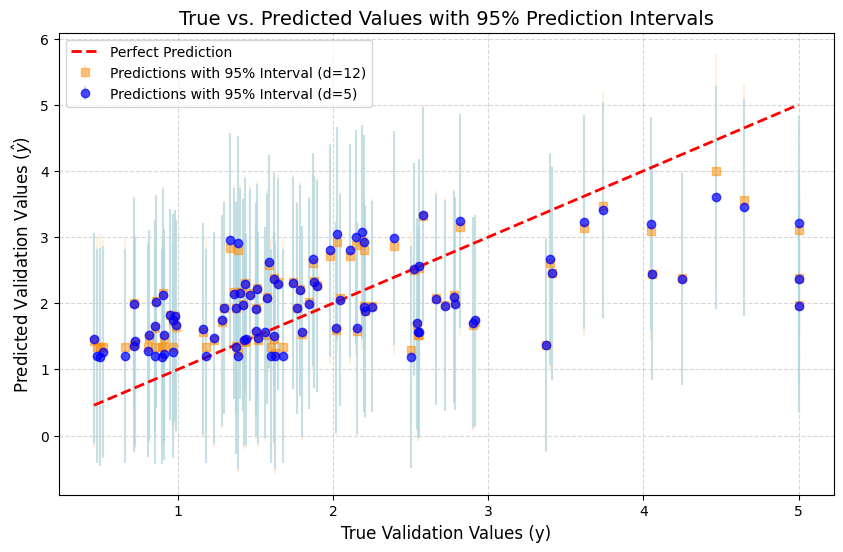

In [11]:
# ============================================================
# CELL 11 — Part 4.1.5: Plot prediction intervals (d=5 and d=12)
# ============================================================

# 1. Calculate error bars (distance from prediction to upper bound)
error_bars_5  = np.array(upper_bounds_5) - np.array(y_val_pred_5)
error_bars_12 = np.array(upper_bounds_12) - np.array(y_val_pred_12)

# 2. Calculate and print Mean Interval Widths (Full width is 2 * error bar)
mean_width_5  = np.mean(2 * error_bars_5)
mean_width_12 = np.mean(2 * error_bars_12)

print(f"Mean interval width, d = 5:  {mean_width_5:.4f}")
print(f"Mean interval width, d = 12: {mean_width_12:.4f}")

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot d=12 first so it sits behind d=5 (since it will likely have wider, messier bars)
plt.errorbar(
    y_val_arr, y_val_pred_12,
    yerr=error_bars_12,
    fmt='s',                      # Squares for d=12
    color='darkorange',
    ecolor='moccasin',
    alpha=0.5,
    label='Predictions with 95% Interval (d=12)'
)

# Plot d=5 overlaying it
plt.errorbar(
    y_val_arr, y_val_pred_5,
    yerr=error_bars_5,
    fmt='o',                     
    color='blue',
    ecolor='lightblue',
    alpha=0.7,
    label='Predictions with 95% Interval (d=5)'
)

# Perfect prediction line
min_val = np.min(y_val_arr)
max_val = np.max(y_val_arr)
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel('True Validation Values (y)', fontsize=12)
plt.ylabel(r'Predicted Validation Values ($\hat{y}$)', fontsize=12)
plt.title('True vs. Predicted Values with 95% Prediction Intervals', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Save and show
plt.savefig('../figures/Prediction_Intervals_Comparison_d5_d12.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
import numpy as np
from sklearn.linear_model import Ridge
from numpy.testing import assert_allclose
from src.ridge_regression import RidgeRegression

# 1. Generate synthetic data for testing
np.random.seed(42)
X_verify = np.random.rand(100, 5) # 100 samples, 5 features
y_verify = np.random.rand(100)    # 100 target values
lambda_val = 1.0

# 2. Fit your custom Ridge model
custom_ridge = RidgeRegression(lambda_=lambda_val)
custom_ridge.fit(X_verify, y_verify)
custom_preds = custom_ridge.predict(X_verify)

# 3. Fit the scikit-learn Ridge model
# In scikit-learn, the regularization parameter lambda is named 'alpha'.
# We set fit_intercept=True because your custom model appends a column of 1s.
sklearn_ridge = Ridge(alpha=lambda_val, fit_intercept=True)
sklearn_ridge.fit(X_verify, y_verify)
sklearn_preds = sklearn_ridge.predict(X_verify)

# 4. Verification Tests
try:
    # Test 1: Compare predictions
    assert_allclose(custom_preds, sklearn_preds, rtol=1e-9, atol=1e-9)
    print("SUCCESS: Predictions match scikit-learn within 10^-9 tolerance!")
    
    # Test 2: Compare learned weights
    # sklearn stores features weights in .coef_ and the bias in .intercept_
    # Your model stores them together, with the bias at the very end.
    sklearn_weights_combined = np.append(sklearn_ridge.coef_, sklearn_ridge.intercept_)
    
    assert_allclose(custom_ridge.weights, sklearn_weights_combined, rtol=1e-9, atol=1e-9)
    print("SUCCESS: Weights and Intercept match scikit-learn within 10^-9 tolerance!")

except AssertionError as e:
    print("FAILURE: Models do not match within tolerance.")
    print(e)

SUCCESS: Predictions match scikit-learn within 10^-9 tolerance!
SUCCESS: Weights and Intercept match scikit-learn within 10^-9 tolerance!


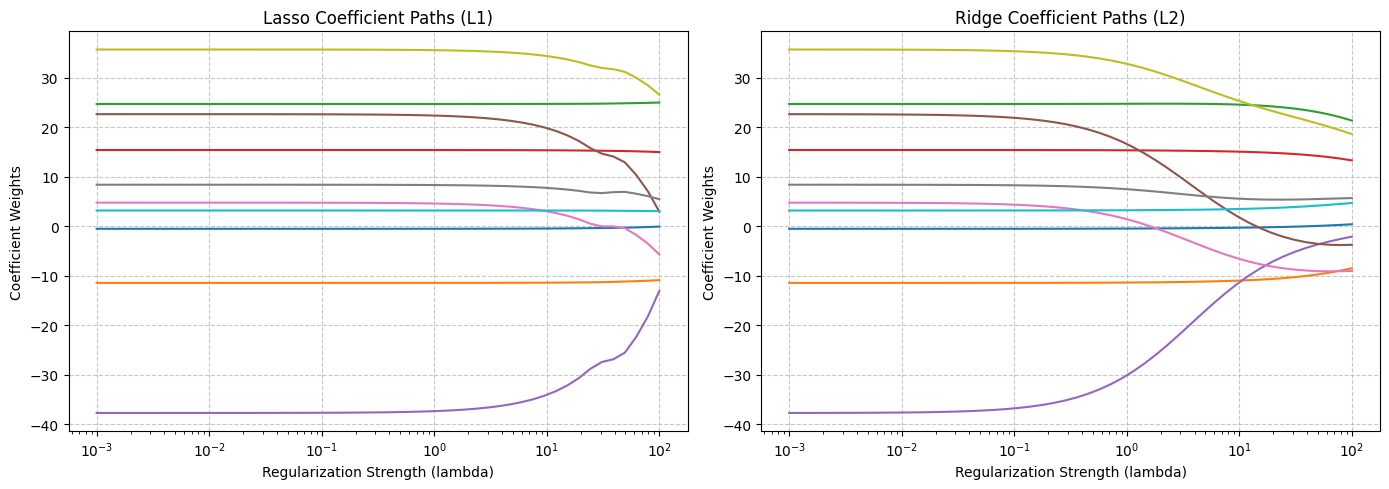

In [13]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from src.lasso_regression import LassoRegression

# 1. Load and Standardize the Diabetes Dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# It is standard practice to standardize X and center y for regularization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_centered = y - np.mean(y)

# 2. Define lambda range: logarithmically spaced between 10^-3 and 10^2
# Using 50 points provides a smooth line for the plot
lambdas = np.logspace(-3, 2, 50)

# 3. Fit models and store weights
lasso_weights = []
ridge_weights = []

for lam in lambdas:
    # Fit Lasso
    lasso_model = LassoRegression(lambda_=lam, max_iter=10000, tol=1e-4)
    lasso_model.fit(X_scaled, y_centered)
    lasso_weights.append(lasso_model.weights.copy())
    
    # Fit Ridge
    ridge_model = RidgeRegression(lambda_=lam)
    ridge_model.fit(X_scaled, y_centered)
    # Note: Your Ridge implementation puts the bias term at the very end of the weights array.
    # We slice with [:-1] to extract only the feature weights for plotting.
    ridge_weights.append(ridge_model.weights[:-1].copy())

lasso_weights = np.array(lasso_weights)
ridge_weights = np.array(ridge_weights)

# 4. Plot the coefficient paths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Lasso Plot
ax1.plot(lambdas, lasso_weights)
ax1.set_xscale('log') # Logarithmic scale for the x-axis
ax1.set_xlabel('Regularization Strength (lambda)')
ax1.set_ylabel('Coefficient Weights')
ax1.set_title('Lasso Coefficient Paths (L1)')
ax1.grid(True, linestyle='--', alpha=0.7)

# Panel 2: Ridge Plot
ax2.plot(lambdas, ridge_weights)
ax2.set_xscale('log') # Logarithmic scale for the x-axis
ax2.set_xlabel('Regularization Strength (lambda)')
ax2.set_ylabel('Coefficient Weights')
ax2.set_title('Ridge Coefficient Paths (L2)')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(
    '../figures/Lasso_Coefficient_Paths_(L1)_and_Ridge_Coefficient_Paths_(L2).pdf',
    format='pdf', 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()


Grid Search Time: 0.3522 seconds | Best Lambda: 29.7635 | Best RMSE: 0.7282
Random Search Time: 0.3502 seconds | Best Lambda: 46.1935 | Best RMSE: 0.7281


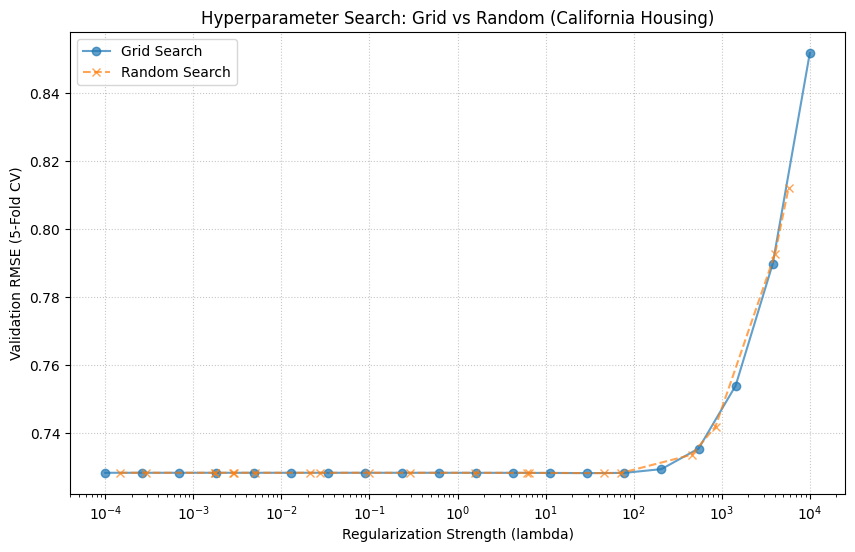

In [14]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# 1. Load and standardize the California Housing dataset
california = fetch_california_housing()
X, y = california.data, california.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# We don't need to strictly center y because your RidgeRegression inherently adds an intercept

# 2. Define lambda values
np.random.seed(42) # For reproducibility
grid_lambdas = np.logspace(-4, 4, 20)
random_lambdas = 10 ** np.random.uniform(-4, 4, 20)

# Sort random_lambdas strictly for cleaner plotting later
random_lambdas = np.sort(random_lambdas)

# 3. Setup 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_search_strategy(lambdas, X_data, y_data):
    rmse_scores = []
    
    for lam in lambdas:
        fold_rmses = []
        for train_idx, val_idx in kf.split(X_data):
            X_tr, X_val = X_data[train_idx], X_data[val_idx]
            y_tr, y_val = y_data[train_idx], y_data[val_idx]
            
            model = RidgeRegression(lambda_=lam)
            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)
            
            rmse = np.sqrt(mean_squared_error(y_val, preds))
            fold_rmses.append(rmse)
            
        rmse_scores.append(np.mean(fold_rmses))
    return np.array(rmse_scores)

# --- Evaluate Grid Search ---
start_time = time.time()
grid_rmses = evaluate_search_strategy(grid_lambdas, X_scaled, y)
grid_time = time.time() - start_time

best_grid_idx = np.argmin(grid_rmses)
best_grid_lam = grid_lambdas[best_grid_idx]

# --- Evaluate Random Search ---
start_time = time.time()
random_rmses = evaluate_search_strategy(random_lambdas, X_scaled, y)
random_time = time.time() - start_time

best_random_idx = np.argmin(random_rmses)
best_random_lam = random_lambdas[best_random_idx]

# 4. Reporting
print(f"Grid Search Time: {grid_time:.4f} seconds | Best Lambda: {best_grid_lam:.4f} | Best RMSE: {grid_rmses[best_grid_idx]:.4f}")
print(f"Random Search Time: {random_time:.4f} seconds | Best Lambda: {best_random_lam:.4f} | Best RMSE: {random_rmses[best_random_idx]:.4f}")

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.plot(grid_lambdas, grid_rmses, marker='o', label='Grid Search', linestyle='-', alpha=0.7)
plt.plot(random_lambdas, random_rmses, marker='x', label='Random Search', linestyle='--', alpha=0.7)
plt.xscale('log')
plt.xlabel('Regularization Strength (lambda)')
plt.ylabel('Validation RMSE (5-Fold CV)')
plt.title('Hyperparameter Search: Grid vs Random (California Housing)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('../figures/Hyperparameter_Search_Grid_vs_Random_(California_Housing).pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()


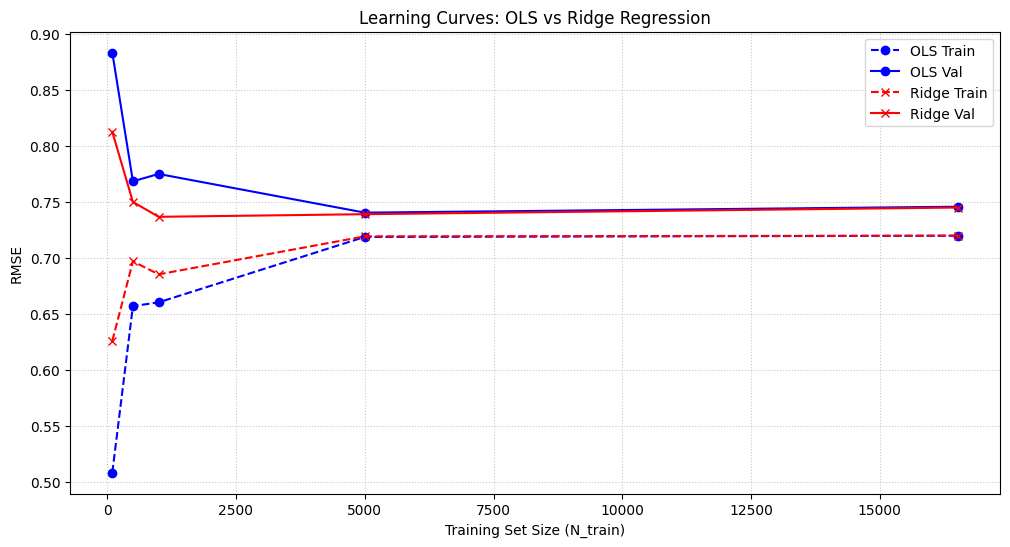

In [15]:
from sklearn.model_selection import train_test_split

# 1. Create a fixed 20% validation set
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 2. Define training sizes and lists to store RMSE
N_train_sizes = [100, 500, 1000, 5000, len(X_train_full)]
best_lambda = best_grid_lam # Using the best lambda found in 4.2.3

ols_train_rmse, ols_val_rmse = [], []
ridge_train_rmse, ridge_val_rmse = [], []

# 3. Train on increasing subsets of data
for n in N_train_sizes:
    # Subset the training data
    X_tr = X_train_full[:n]
    y_tr = y_train_full[:n]
    
    # --- OLS (Ridge with lambda = 0) ---
    ols = RidgeRegression(lambda_=0.0)
    ols.fit(X_tr, y_tr)
    ols_train_rmse.append(np.sqrt(mean_squared_error(y_tr, ols.predict(X_tr))))
    ols_val_rmse.append(np.sqrt(mean_squared_error(y_val, ols.predict(X_val))))
    
    # --- Ridge (with best lambda) ---
    ridge = RidgeRegression(lambda_=best_lambda)
    ridge.fit(X_tr, y_tr)
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_tr, ridge.predict(X_tr))))
    ridge_val_rmse.append(np.sqrt(mean_squared_error(y_val, ridge.predict(X_val))))

# 4. Plotting the Learning Curves
plt.figure(figsize=(12, 6))

# Plot OLS Curves
plt.plot(N_train_sizes, ols_train_rmse, marker='o', color='blue', linestyle='--', label='OLS Train')
plt.plot(N_train_sizes, ols_val_rmse, marker='o', color='blue', linestyle='-', label='OLS Val')

# Plot Ridge Curves
plt.plot(N_train_sizes, ridge_train_rmse, marker='x', color='red', linestyle='--', label='Ridge Train')
plt.plot(N_train_sizes, ridge_val_rmse, marker='x', color='red', linestyle='-', label='Ridge Val')

plt.xlabel('Training Set Size (N_train)')
plt.ylabel('RMSE')
plt.title('Learning Curves: OLS vs Ridge Regression')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('../figures/Learning_Curves_OLS_vs_Ridge_Regression.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# ============================================================
# CELL X — Logistic Regression Sanity Check
# ============================================================
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

# Import YOUR custom model
from src.logistic_regression import LogisticRegression as CustomLogisticRegression

# 1. Generate synthetic classification data
X_syn, y_syn = make_classification(n_samples=500, n_features=5, random_state=42)

# 2. Standardize the features (CRITICAL for gradient descent)
scaler = StandardScaler()
X_syn_scaled = scaler.fit_transform(X_syn)

# 3. Fit sklearn model (Unregularized for a fair comparison)
sk_model = SklearnLogisticRegression(penalty=None, solver='lbfgs')
sk_model.fit(X_syn_scaled, y_syn)
sk_preds = sk_model.predict_proba(X_syn_scaled)[:, 1] # Get probabilities for class 1

# 4. Fit YOUR custom model 
# High learning rate (1.0) and iterations (10000) to ensure exact mathematical convergence
my_model = CustomLogisticRegression(lr=1.0, max_iter=10000) 
my_model.fit(X_syn_scaled, y_syn)
my_preds = my_model.predict_proba(X_syn_scaled)

# 5. The Sanity Check
is_close = np.allclose(sk_preds, my_preds, atol=1e-6)
print(f"Sanity check passed (Tolerance 1e-6): {is_close}")

# 6. Print the metrics needed for your write-up
iterations_run = len(my_model.loss_history)
final_loss = my_model.loss_history[-1]

print(f"Total Iterations: {iterations_run}")
print(f"Final Cross-Entropy Loss: {final_loss:.6f}")

Sanity check passed (Tolerance 1e-6): False
Total Iterations: 10000
Final Cross-Entropy Loss: 0.279364


In [17]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from src.logistic_regression import MulticlassLogisticRegressionOvR

# 1. Load the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target

# 2. Split into training and testing sets (e.g., 70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scale the features (Crucial for gradient descent to converge smoothly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the OvR Multiclass model
# Note: Using a smaller learning rate and L2 penalty for stability
ovr_model = MulticlassLogisticRegressionOvR(lr=0.01, lambda_=0.1, max_iter=2000)
ovr_model.fit(X_train_scaled, y_train)

# 5. Predict on the test set
y_pred = ovr_model.predict(X_test_scaled)

# 6. Evaluate and report Accuracy and Confusion Matrix
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 98.15%

Confusion Matrix:
[[19  0  0]
 [ 1 20  0]
 [ 0  0 14]]


In [18]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from src.naive_bayes import GaussianNaiveBayes

# Load Data
wine = load_wine()
X, y = wine.data, wine.target

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features (Crucial for Logistic Regression, optional but fine for NB)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 1. Train and Evaluate Gaussian Naive Bayes ---
nb_model = GaussianNaiveBayes()
nb_model.fit(X_train_scaled, y_train)
nb_preds = nb_model.predict(X_test_scaled)

print("--- Gaussian Naive Bayes ---")
print(f"Accuracy:  {accuracy_score(y_test, nb_preds):.4f}")
print(f"Precision: {precision_score(y_test, nb_preds, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, nb_preds, average='macro'):.4f}")
print(f"F1 Score:  {f1_score(y_test, nb_preds, average='macro'):.4f}\n")

# --- 2. Train and Evaluate Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("--- Logistic Regression ---")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.4f}")
print(f"Precision: {precision_score(y_test, lr_preds, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, lr_preds, average='macro'):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_preds, average='macro'):.4f}")

--- Gaussian Naive Bayes ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

--- Logistic Regression ---
Accuracy:  0.9815
Precision: 0.9778
Recall:    0.9841
F1 Score:  0.9804


Loading data...
Extracting features...
Training models...
Evaluating models...

--- Logistic Regression ---
F1 Score: 0.9151
AUC-ROC:  0.9789

--- Gaussian Naive Bayes ---
F1 Score: 0.5692
AUC-ROC:  0.5116


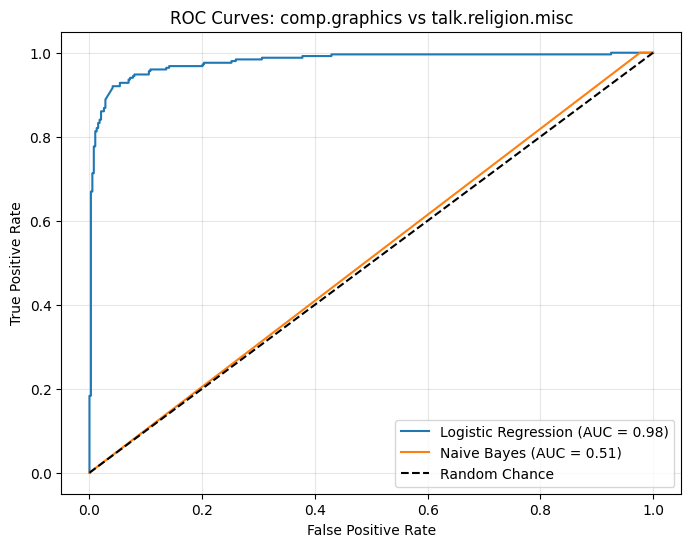

In [19]:

%load_ext autoreload
%autoreload 2

from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# --Custom Imports Go Here ---
from src.text_features import BagOfWords, TfidfTransformer
from src.logistic_regression import LogisticRegression
from src.naive_bayes import GaussianNaiveBayes
# -----------------------------------

# 1. Load the 20 Newsgroups Data
print("Loading data...")
categories = ['comp.graphics', 'talk.religion.misc']
data_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
data_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

y_train = data_train.target
y_test = data_test.target

# 2. Extract Features from Scratch
print("Extracting features...")
bow = BagOfWords(max_features=5000)
X_train_counts = bow.fit(data_train.data).transform(data_train.data)
X_test_counts = bow.transform(data_test.data)

tfidf = TfidfTransformer()
X_train_tfidf = tfidf.fit(X_train_counts).transform(X_train_counts)
X_test_tfidf = tfidf.transform(X_test_counts)

# 3. Train Models
print("Training models...")
# Using the models imported from your src folder
lr_model = LogisticRegression(lr=0.1, lambda_=0.1, max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

nb_model = GaussianNaiveBayes()
nb_model.fit(X_train_tfidf, y_train)

# 4. Predict and Evaluate
print("Evaluating models...")
# Logistic Regression Outputs
lr_probs = lr_model.predict_proba(X_test_tfidf)
lr_preds = lr_model.predict(X_test_tfidf)

# Naive Bayes Outputs
nb_probs = nb_model.predict_proba(X_test_tfidf)[:, 1] 
nb_preds = nb_model.predict(X_test_tfidf)

# Metrics
print("\n--- Logistic Regression ---")
print(f"F1 Score: {f1_score(y_test, lr_preds):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, lr_probs):.4f}")

print("\n--- Gaussian Naive Bayes ---")
print(f"F1 Score: {f1_score(y_test, nb_preds):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, nb_probs):.4f}")

# 5. Plot ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_score(y_test, nb_probs):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

plt.title('ROC Curves: comp.graphics vs talk.religion.misc')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('../figures/ROC_Curves_comp_graphics_vs_talk_religion_misc.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# %%
# ============================================================
# Optimized: Finding Words Unique to One Class
# ============================================================
import re
from sklearn.datasets import fetch_20newsgroups

print("Loading data and processing vocabularies...")

# 1. Load the data directly in this cell to ensure data_train and y_train are defined
categories = ['comp.graphics', 'talk.religion.misc']
data_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
y_train = data_train.target

# 2. Join all documents for each class into single massive strings 
# This avoids looping over individual documents during tokenization
graphics_text = " ".join([data_train.data[i] for i in range(len(y_train)) if y_train[i] == 0])
religion_text = " ".join([data_train.data[i] for i in range(len(y_train)) if y_train[i] == 1])

# 3. Tokenize and convert directly to sets in one step
# Using the exact same regex pattern from your custom BagOfWords class
regex_pattern = r'\b[a-z]{2,}\b'
graphics_vocab = set(re.findall(regex_pattern, graphics_text.lower()))
religion_vocab = set(re.findall(regex_pattern, religion_text.lower()))

# 4. Calculate words unique to each class using standard set difference
unique_to_graphics = graphics_vocab - religion_vocab
unique_to_religion = religion_vocab - graphics_vocab

total_unique_words = len(unique_to_graphics) + len(unique_to_religion)

# 5. Output results
print(f"Words unique to comp.graphics (0):  {len(unique_to_graphics)}")
print(f"Words unique to talk.religion (1):  {len(unique_to_religion)}")
print(f"Total words appearing in only one class: {total_unique_words}")

Loading data and processing vocabularies...
Words unique to comp.graphics (0):  6042
Words unique to talk.religion (1):  5587
Total words appearing in only one class: 11629


In [22]:
# %%
# ============================================================
# Fully Self-Contained: Evaluating TF-IDF vs BoW Impact
# ============================================================
import sys
import os
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import f1_score, roc_auc_score

# Ensure Python can find your 'src' folder
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from src.logistic_regression import LogisticRegression
from src.naive_bayes import GaussianNaiveBayes

print("1. Loading train and test datasets...")
categories = ['comp.graphics', 'talk.religion.misc']
data_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
data_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

X_train_raw = data_train.data
y_train = data_train.target
X_test_raw = data_test.data
y_test = data_test.target

print("2. Generating Count Vectors (BoW)...")
bow = BagOfWords(max_features=5000)
bow.fit(X_train_raw)
X_train_counts = bow.transform(X_train_raw)
X_test_counts = bow.transform(X_test_raw)

print("3. Generating TF-IDF Vectors...")
tfidf_transformer = TfidfTransformer()
tfidf_transformer.fit(X_train_counts)
X_train_tfidf = tfidf_transformer.transform(X_train_counts)
X_test_tfidf = tfidf_transformer.transform(X_test_counts)

# --- FOOLPROOF PROBABILITY EXTRACTOR ---
def get_positive_probs(probs):
    """Safely handles both 1D arrays (custom models) and 2D arrays (sklearn style)"""
    import numpy as np
    probs = np.array(probs)
    if len(probs.shape) == 2:
        return probs[:, 1]
    return probs
# ---------------------------------------

print("\n=== Evaluating Bag of Words (BoW) ===")
# Logistic Regression on BoW
lr_bow = LogisticRegression(lr=0.1, lambda_=0.1, max_iter=1000)
lr_bow.fit(X_train_counts, y_train)
lr_bow_preds = lr_bow.predict(X_test_counts)
lr_bow_probs = get_positive_probs(lr_bow.predict_proba(X_test_counts))

# Naive Bayes on BoW
nb_bow = GaussianNaiveBayes()
nb_bow.fit(X_train_counts, y_train)
nb_bow_preds = nb_bow.predict(X_test_counts)
nb_bow_probs = get_positive_probs(nb_bow.predict_proba(X_test_counts))

print(f"Logistic Regression (BoW) -> F1: {f1_score(y_test, lr_bow_preds):.4f} | AUC-ROC: {roc_auc_score(y_test, lr_bow_probs):.4f}")
print(f"Naive Bayes (BoW)         -> F1: {f1_score(y_test, nb_bow_preds):.4f} | AUC-ROC: {roc_auc_score(y_test, nb_bow_probs):.4f}")


print("\n=== Evaluating TF-IDF ===")
# Logistic Regression on TF-IDF
lr_tfidf = LogisticRegression(lr=0.1, lambda_=0.1, max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
lr_tfidf_preds = lr_tfidf.predict(X_test_tfidf)
lr_tfidf_probs = get_positive_probs(lr_tfidf.predict_proba(X_test_tfidf))

# Naive Bayes on TF-IDF
nb_tfidf = GaussianNaiveBayes()
nb_tfidf.fit(X_train_tfidf, y_train)
nb_tfidf_preds = nb_tfidf.predict(X_test_tfidf)
nb_tfidf_probs = get_positive_probs(nb_tfidf.predict_proba(X_test_tfidf))

print(f"Logistic Regression (TF-IDF) -> F1: {f1_score(y_test, lr_tfidf_preds):.4f} | AUC-ROC: {roc_auc_score(y_test, lr_tfidf_probs):.4f}")
print(f"Naive Bayes (TF-IDF)         -> F1: {f1_score(y_test, nb_tfidf_preds):.4f} | AUC-ROC: {roc_auc_score(y_test, nb_tfidf_probs):.4f}")

1. Loading train and test datasets...
2. Generating Count Vectors (BoW)...
3. Generating TF-IDF Vectors...

=== Evaluating Bag of Words (BoW) ===
Logistic Regression (BoW) -> F1: 0.8535 | AUC-ROC: 0.9609
Naive Bayes (BoW)         -> F1: 0.5698 | AUC-ROC: 0.5129

=== Evaluating TF-IDF ===
Logistic Regression (TF-IDF) -> F1: 0.9151 | AUC-ROC: 0.9789
Naive Bayes (TF-IDF)         -> F1: 0.5692 | AUC-ROC: 0.5116
